In [ ]:
%env USE_FLAX=NO
%env USE_JAX=NO
%env USE_TF=NO

%cd /kaggle/working
!rm -rf thesis
!git clone https://github.com/vinhhna/thesis.git

%cd /kaggle/working/thesis/SparseVLMs
!git rev-parse --short HEAD

In [ ]:
!python -m pip install --upgrade pip setuptools wheel

!python -m pip install --force-reinstall --no-deps torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu121

!python -m pip install "numpy<2" protobuf sentencepiece shortuuid
!python -m pip install transformers==4.37.2 tokenizers==0.15.1 accelerate==0.21.0 peft==0.7.1
!python -m pip install einops==0.6.1 einops-exts==0.0.4 timm==0.6.13 "markdown2[all]" matplotlib
!python -m pip uninstall -y bitsandbytes jax jaxlib flax optax chex orbax-checkpoint

print("Restart the Kaggle kernel after this cell finishes, then continue from Cell 3.")

In [1]:
%cd /kaggle/working/thesis/SparseVLMs

import os
import sys
import torch

REPO_ROOT = "/kaggle/working/thesis"
LLAVA_ROOT = "/kaggle/working/thesis/SparseVLMs"
CSV_PATH = f"{REPO_ROOT}/failure_mining_set.csv"
OUTPUT_DIR = "/kaggle/working/sparse_selected_token_visualizations"
TRACE_JSONL = f"{OUTPUT_DIR}/selected_token_traces.jsonl"

os.environ["USE_FLAX"] = "NO"
os.environ["USE_JAX"] = "NO"
os.environ["USE_TF"] = "NO"
os.environ["PYTHONPATH"] = LLAVA_ROOT
if LLAVA_ROOT not in sys.path:
    sys.path.insert(0, LLAVA_ROOT)

print("Torch:", torch.__version__)
print("Torch CUDA build:", torch.version.cuda)

/kaggle/working/thesis/SparseVLMs
Torch: 2.5.1+cu121
Torch CUDA build: 12.1


In [2]:
from pathlib import Path


def patch_sparse_token_trace():
    """Patch SparseVLMs so each sparse pruning layer records selected original patches."""
    path = Path(LLAVA_ROOT) / "llava/model/language_model/modelling_sparse_llama.py"
    text = path.read_text(encoding="utf-8")

    if "visual_token_sources = torch.arange" in text:
        print("Sparse token trace patch already present.")
        return

    def replace_once(old, new):
        nonlocal text
        if old not in text:
            raise RuntimeError("Patch anchor not found. The SparseVLMs source may have changed.")
        text = text.replace(old, new, 1)

    replace_once(
        """        self.causal_inference_cuda_time = 0
        # ------------------------------------------- Sparse ----------------------------------------------""",
        """        self.causal_inference_cuda_time = 0
        self.capture_visual_tokens = False
        self.visual_token_trace = []
        # ------------------------------------------- Sparse ----------------------------------------------""",
    )
    replace_once(
        """        v_token_start = pre_prompt_length_list[0] if len(pre_prompt_length_list) != 0 else 0 # 35
        text_token_start = v_token_start + image_shape # 611
        v_token_num = image_shape""",
        """        v_token_start = pre_prompt_length_list[0] if len(pre_prompt_length_list) != 0 else 0 # 35
        text_token_start = v_token_start + image_shape # 611
        v_token_num = image_shape

        capture_visual_tokens = (
            getattr(self, "capture_visual_tokens", False)
            and len(pre_prompt_length_list) != 0
            and hidden_states.shape[1] != 1
        )
        if capture_visual_tokens:
            self.visual_token_trace = []
            visual_token_sources = torch.arange(
                int(v_token_num), device=hidden_states.device, dtype=torch.long
            ).unsqueeze(0).expand(B, -1)
        else:
            visual_token_sources = None""",
    )
    replace_once(
        """                    pred_score_vis, s_flag, relation_vis_text = attn_postprocess_mmr(attn_logits, visual_states, v_token_start, v_token_num, text_token_start, t_token_idx, layer_idx,retained_tokens) # B, L_v
                    policy = torch.ones(B, hidden_states.shape[1], dtype=hidden_states.dtype, device=hidden_states.device)""",
        """                    pred_score_vis, s_flag, relation_vis_text = attn_postprocess_mmr(attn_logits, visual_states, v_token_start, v_token_num, text_token_start, t_token_idx, layer_idx,retained_tokens) # B, L_v

                    if capture_visual_tokens:
                        selected_current_idx = torch.where(pred_score_vis[0].bool())[0]
                        selected_original_idx = visual_token_sources[0, selected_current_idx]
                        selected_original_idx = selected_original_idx[selected_original_idx >= 0]
                        current_visual_tokens = int(v_token_num.item()) if isinstance(v_token_num, torch.Tensor) else int(v_token_num)
                        merged_tokens_present = int((visual_token_sources[0] < 0).sum().item())
                        self.visual_token_trace.append({
                            "layer": int(layer_idx),
                            "current_visual_tokens": current_visual_tokens,
                            "selected_original_indices": selected_original_idx.detach().cpu().tolist(),
                            "merged_tokens_present": merged_tokens_present,
                        })

                    policy = torch.ones(B, hidden_states.shape[1], dtype=hidden_states.dtype, device=hidden_states.device)""",
    )
    replace_once(
        """                        layer_outputs = (select_and_merge_token, layer_outputs[1])  # B, L, C
                        position_ids = position_ids[:, :len(select_token_idx[0])+cluster_num]
                        prev_decision = policy
                        # update
                        v_token_num = pred_score_vis.sum() + cluster_num # B == 1
                        # print(layer_idx, v_token_num)
                        text_token_start = v_token_start + v_token_num""",
        """                        layer_outputs = (select_and_merge_token, layer_outputs[1])  # B, L, C
                        position_ids = position_ids[:, :len(select_token_idx[0])+cluster_num]
                        prev_decision = policy
                        # update
                        v_token_num = pred_score_vis.sum() + cluster_num # B == 1
                        # print(layer_idx, v_token_num)
                        text_token_start = v_token_start + v_token_num
                        if capture_visual_tokens:
                            selected_current_idx = torch.where(pred_score_vis[0].bool())[0]
                            selected_sources = visual_token_sources[:, selected_current_idx]
                            merged_sources = torch.full((B, cluster_num), -1, dtype=torch.long, device=hidden_states.device)
                            visual_token_sources = torch.cat((selected_sources, merged_sources), dim=1)""",
    )
    replace_once(
        """                        # update
                        v_token_num = pred_score_vis.sum() # B == 1
                        # print(layer_idx, v_token_num)
                        text_token_start = v_token_start + v_token_num""",
        """                        # update
                        v_token_num = pred_score_vis.sum() # B == 1
                        # print(layer_idx, v_token_num)
                        text_token_start = v_token_start + v_token_num
                        if capture_visual_tokens:
                            selected_current_idx = torch.where(pred_score_vis[0].bool())[0]
                            visual_token_sources = visual_token_sources[:, selected_current_idx]""",
    )

    path.write_text(text, encoding="utf-8")
    print("Patched:", path)


patch_sparse_token_trace()

Sparse token trace patch already present.


In [3]:
import csv
import json
import math
import time
from pathlib import Path

import torch
from PIL import Image, ImageDraw, ImageFont, ImageOps
from IPython.display import Image as DisplayImage
from IPython.display import Markdown, display

from llava.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN
from llava.conversation import conv_templates
from llava.mm_utils import expand2square, get_model_name_from_path, process_images, tokenizer_image_token
from llava.model.builder import load_pretrained_model
from llava.utils import disable_torch_init


MODEL_PATH = "liuhaotian/llava-v1.5-7b"
CONV_MODE = "llava_v1"
MAX_NEW_TOKENS = 64
RETAINED_TOKENS = 64
TARGET_ROWS_1_INDEXED = [1, 15, 44, 45, 50, 59, 68, 98]
VIS_LAYER = 15
SAVE_ALL_LAYERS = True
SHOW_ALL_LAYERS = False


def build_prompt(question):
    conv = conv_templates[CONV_MODE].copy()
    conv.append_message(conv.roles[0], DEFAULT_IMAGE_TOKEN + "\n" + question)
    conv.append_message(conv.roles[1], None)
    return conv.get_prompt()


def prepare_image_tensor(image):
    image_sizes = [image.size]
    images_tensor = process_images([image], image_processor, model.config)
    if isinstance(images_tensor, list):
        images_tensor = [
            image_tensor.to(model.device, dtype=torch.float16)
            for image_tensor in images_tensor
        ]
    else:
        images_tensor = images_tensor.to(model.device, dtype=torch.float16)
    return images_tensor, image_sizes


def sparse_answer_and_trace(image_path, question):
    prompt = build_prompt(question)
    image = Image.open(image_path).convert("RGB")
    images_tensor, image_sizes = prepare_image_tensor(image)
    input_ids = tokenizer_image_token(
        prompt,
        tokenizer,
        IMAGE_TOKEN_INDEX,
        return_tensors="pt",
    ).unsqueeze(0).to(model.device)

    sparse_core = model.get_model()
    sparse_core.capture_visual_tokens = True
    sparse_core.visual_token_trace = []
    try:
        with torch.inference_mode():
            output_ids = model.generate(
                inputs=input_ids,
                images=images_tensor,
                image_sizes=image_sizes,
                retained_tokens=RETAINED_TOKENS,
                do_sample=False,
                num_beams=1,
                max_new_tokens=MAX_NEW_TOKENS,
                use_cache=True,
            )
        trace = [dict(item) for item in sparse_core.visual_token_trace]
    finally:
        sparse_core.capture_visual_tokens = False

    answer = tokenizer.batch_decode(output_ids, skip_special_tokens=True)[0].strip()
    return answer, trace


def clip_input_view(image):
    crop_size = image_processor.crop_size
    if isinstance(crop_size, dict):
        side = int(crop_size.get("height", crop_size.get("width", 336)))
    else:
        side = int(crop_size)

    if getattr(model.config, "image_aspect_ratio", None) == "pad":
        background = tuple(int(x * 255) for x in image_processor.image_mean)
        image = expand2square(image, background)
        return image.resize((side, side), Image.Resampling.BICUBIC)

    return ImageOps.fit(
        image,
        (side, side),
        method=Image.Resampling.BICUBIC,
        centering=(0.5, 0.5),
    )


def overlay_selected_tokens(image, selected_indices, grid_size, fade=0.72):
    base = clip_input_view(image).convert("RGB")
    white = Image.new("RGB", base.size, "white")
    canvas = Image.blend(base, white, fade).convert("RGBA")
    source = base.convert("RGBA")
    highlight = Image.new("RGBA", base.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(highlight, "RGBA")

    selected = {
        int(idx)
        for idx in selected_indices
        if 0 <= int(idx) < grid_size * grid_size
    }
    width, height = base.size

    for idx in sorted(selected):
        row, col = divmod(idx, grid_size)
        left = round(col * width / grid_size)
        top = round(row * height / grid_size)
        right = round((col + 1) * width / grid_size)
        bottom = round((row + 1) * height / grid_size)
        box = (left, top, right, bottom)
        canvas.paste(source.crop(box), box)
        draw.rectangle(box, fill=(220, 0, 0, 55), outline=(185, 0, 0, 235), width=2)

    return Image.alpha_composite(canvas, highlight).convert("RGB")


def make_side_by_side(original, overlay, right_label):
    target_h = overlay.height
    left = original.copy().convert("RGB")
    left.thumbnail((target_h, target_h), Image.Resampling.LANCZOS)
    right = overlay.convert("RGB")

    header_h = 34
    gap = 22
    margin = 12
    width = left.width + right.width + gap + margin * 2
    height = max(left.height, right.height) + header_h + margin
    canvas = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(canvas)
    font = ImageFont.load_default()

    left_x = margin
    right_x = margin + left.width + gap
    image_y = header_h
    left_y = image_y + (max(left.height, right.height) - left.height) // 2
    right_y = image_y

    draw.text((left_x, 10), "Full image", fill=(0, 0, 0), font=font)
    draw.text((right_x, 10), right_label, fill=(0, 0, 0), font=font)
    canvas.paste(left, (left_x, left_y))
    canvas.paste(right, (right_x, right_y))
    return canvas


def choose_trace(trace, layer=VIS_LAYER):
    by_layer = {int(item["layer"]): item for item in trace}
    if layer in by_layer:
        return by_layer[layer]
    if trace:
        return trace[-1]
    return {"layer": None, "selected_original_indices": []}


def patch_grid_size():
    image_shape = getattr(model, "image_shape", 576)
    return int(round(math.sqrt(int(image_shape))))


def save_overlay(row_num, case_id, layer, image, selected_indices, grid_size, output_dir):
    overlay = overlay_selected_tokens(image, selected_indices, grid_size)
    path = output_dir / f"{row_num:03d}_{case_id}_layer{layer}_selected_tokens.png"
    overlay.save(path)
    return overlay, path


def run_selected_token_visualization():
    output_dir = Path(OUTPUT_DIR)
    output_dir.mkdir(parents=True, exist_ok=True)

    with open(CSV_PATH, "r", encoding="utf-8", newline="") as f:
        rows = list(csv.DictReader(f))

    selected_rows = [(row_num, rows[row_num - 1]) for row_num in TARGET_ROWS_1_INDEXED]
    grid_size = patch_grid_size()

    print("Rows:", TARGET_ROWS_1_INDEXED)
    print("Patch grid:", grid_size, "x", grid_size)
    print("Output dir:", output_dir)
    print()

    with open(TRACE_JSONL, "w", encoding="utf-8") as trace_file:
        for row_num, row in selected_rows:
            image_path = Path(REPO_ROOT) / row["image_path"]
            image = Image.open(image_path).convert("RGB")
            case_id = row["case_id"]
            question = row["question"]
            ground_truth = row.get("ground_truth", "")
            question_type = row.get("question_type", "")

            display(Markdown(f"### Row {row_num}: `{case_id}` | `{question_type}`"))
            print("Question:", question)
            print("Ground truth:", ground_truth)

            start = time.time()
            answer, trace = sparse_answer_and_trace(image_path, question)
            elapsed = time.time() - start

            chosen = choose_trace(trace)
            final_layer = chosen["layer"]
            layer_paths = {}
            final_overlay = None

            layers_to_save = trace if SAVE_ALL_LAYERS else [chosen]
            for item in layers_to_save:
                layer = int(item["layer"])
                overlay, layer_path = save_overlay(
                    row_num,
                    case_id,
                    layer,
                    image,
                    item["selected_original_indices"],
                    grid_size,
                    output_dir,
                )
                layer_paths[str(layer)] = str(layer_path)
                if layer == final_layer:
                    final_overlay = overlay

            if final_overlay is None:
                final_overlay, layer_path = save_overlay(
                    row_num,
                    case_id,
                    final_layer,
                    image,
                    chosen["selected_original_indices"],
                    grid_size,
                    output_dir,
                )
                layer_paths[str(final_layer)] = str(layer_path)

            pair = make_side_by_side(
                image,
                final_overlay,
                f"Selected tokens, layer {final_layer}",
            )
            pair_path = output_dir / f"{row_num:03d}_{case_id}_full_vs_selected_layer{final_layer}.png"
            pair.save(pair_path)

            display(DisplayImage(filename=str(pair_path), width=900))
            if SHOW_ALL_LAYERS:
                for layer_path in layer_paths.values():
                    display(DisplayImage(filename=layer_path, width=420))

            print("Sparse answer:", answer)
            print("Selected original patches:", len(chosen["selected_original_indices"]))
            print("Trace layers:", [item["layer"] for item in trace])
            print("Seconds:", round(elapsed, 2))
            print("-" * 100, flush=True)

            trace_file.write(json.dumps({
                "row": row_num,
                "case_id": case_id,
                "dataset": row["dataset"],
                "image_path": row["image_path"],
                "question": question,
                "ground_truth": ground_truth,
                "question_type": question_type,
                "retained_tokens": RETAINED_TOKENS,
                "sparse_answer": answer,
                "trace": trace,
                "visualization": str(pair_path),
                "layer_visualizations": layer_paths,
                "inference_seconds": elapsed,
            }, ensure_ascii=False) + "\n")
            trace_file.flush()
            torch.cuda.empty_cache()

    print("Done.")
    print("Trace JSONL:", TRACE_JSONL)


disable_torch_init()
torch.backends.cuda.matmul.allow_tf32 = True

model_name = get_model_name_from_path(MODEL_PATH)

load_start = time.time()
tokenizer, model, image_processor, context_len = load_pretrained_model(
    MODEL_PATH,
    model_base=None,
    model_name=model_name,
    load_4bit=False,
    load_8bit=False,
    device="cuda",
    dynamic_sparse=True,
)
model.eval()

print("Loaded:", MODEL_PATH)
print("Conversation mode:", CONV_MODE)
print("Context length:", context_len)
print("Retained tokens:", RETAINED_TOKENS)
print("Load seconds:", round(time.time() - load_start, 2))

2026-05-11 04:57:56.829592: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778475476.853610     192 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778475476.860402     192 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778475476.879956     192 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778475476.879983     192 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778475476.879986     192 computation_placer.cc:177] computation placer alr

tokenizer_config.json:   0%|          | 0.00/749 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

2026-05-11 04:58:07,869 - llava.model.builder - INFO - Start Sparse Inference...


...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loaded: liuhaotian/llava-v1.5-7b
Conversation mode: llava_v1
Context length: 2048
Retained tokens: 64
Load seconds: 100.42


Rows: [1, 15, 44, 45, 50, 59, 68, 98]
Patch grid: 24 x 24
Output dir: /kaggle/working/sparse_selected_token_visualizations



### Row 1: `GQA_VAL_001` | `rel`

Question: Is the white toilet paper to the left or to the right of the toilet?
Ground truth: left
equal token num until now: 64.8125 ,total_layers_cuda_time:880.7642211914062,TFLOPs_avg_sample:0.9463370874879999


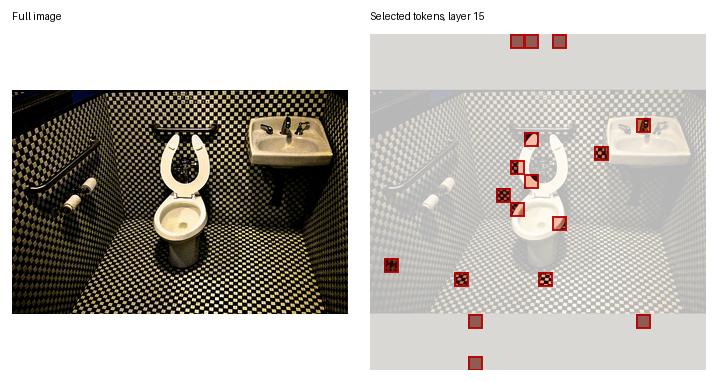

Sparse answer: The white toilet paper is to the right of the toilet.
Selected original patches: 17
Trace layers: [2, 6, 15]
Seconds: 4.68
----------------------------------------------------------------------------------------------------


### Row 15: `GQA_VAL_015` | `attr`

Question: On which side of the photo are the wood cabinets, the left or the right?
Ground truth: right
equal token num until now: 64.8125 ,total_layers_cuda_time:1258.2506713867188,TFLOPs_avg_sample:0.9397859778559999


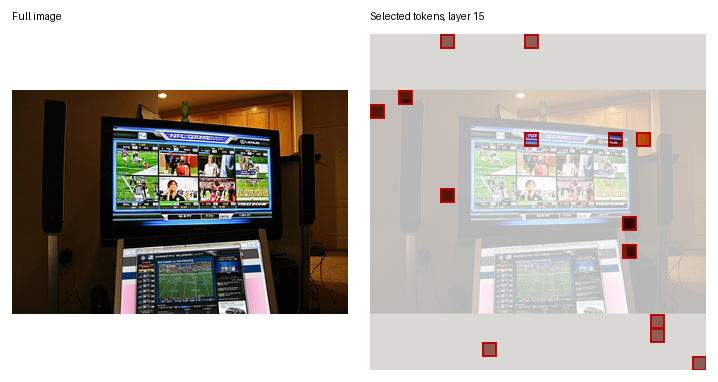

Sparse answer: Left
Selected original patches: 14
Trace layers: [2, 6, 15]
Seconds: 0.55
----------------------------------------------------------------------------------------------------


### Row 44: `GQA_VAL_044` | `cat`

Question: Which kind of food is fried?
Ground truth: egg
equal token num until now: 64.8125 ,total_layers_cuda_time:1633.4915466308594,TFLOPs_avg_sample:0.9179575965013334


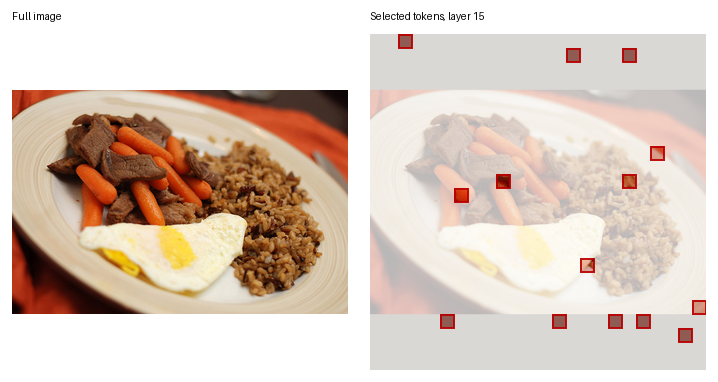

Sparse answer: The food that is fried is rice.
Selected original patches: 14
Trace layers: [2, 6, 15]
Seconds: 1.04
----------------------------------------------------------------------------------------------------


### Row 45: `GQA_VAL_045` | `cat`

Question: How is the black item of clothing called?
Ground truth: suit
equal token num until now: 64.8125 ,total_layers_cuda_time:2009.1603088378906,TFLOPs_avg_sample:0.908679938048


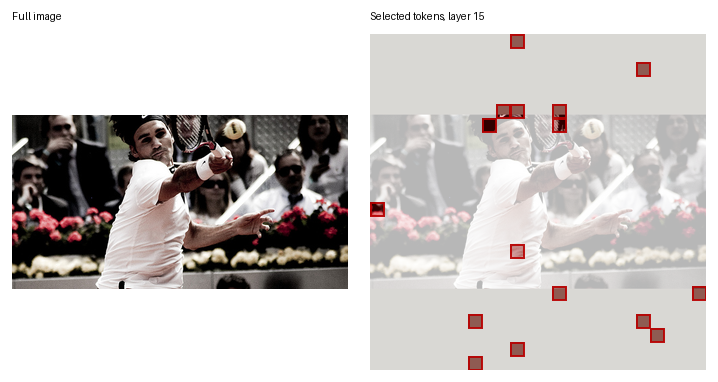

Sparse answer: The black item of clothing is a shirt.
Selected original patches: 16
Trace layers: [2, 6, 15]
Seconds: 1.16
----------------------------------------------------------------------------------------------------


### Row 50: `GQA_VAL_050` | `cat`

Question: What kind of clothing is not white?
Ground truth: suit
equal token num until now: 64.8125 ,total_layers_cuda_time:2385.1509704589844,TFLOPs_avg_sample:0.9018041171968


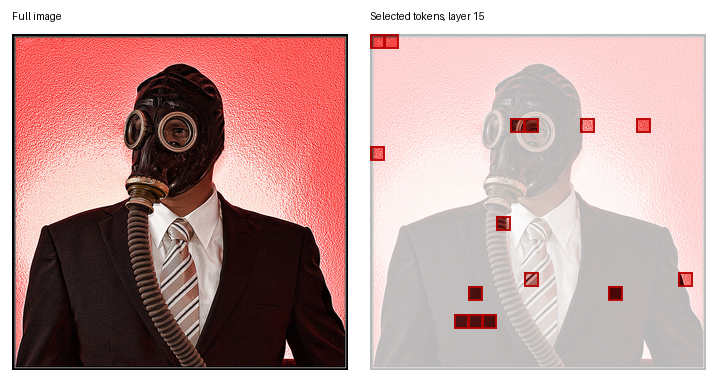

Sparse answer: The mask is not white.
Selected original patches: 15
Trace layers: [2, 6, 15]
Seconds: 0.86
----------------------------------------------------------------------------------------------------


### Row 59: `GQA_VAL_059` | `global`

Question: Which place is pictured?
Ground truth: patio
equal token num until now: 64.8125 ,total_layers_cuda_time:2760.1270446777344,TFLOPs_avg_sample:0.8961293025279999


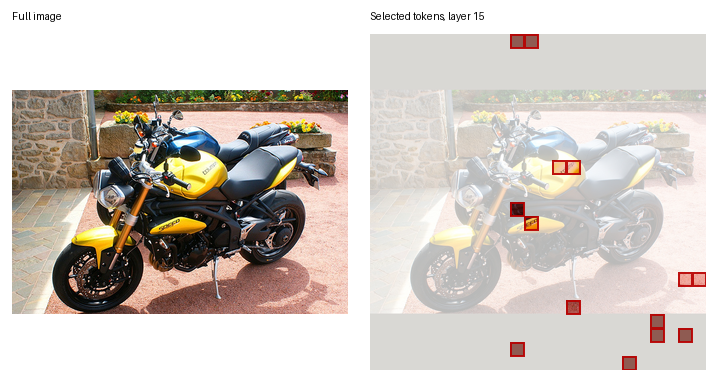

Sparse answer: A parking lot is pictured in the image.
Selected original patches: 14
Trace layers: [2, 6, 15]
Seconds: 1.23
----------------------------------------------------------------------------------------------------


### Row 68: `GQA_VAL_068` | `global`

Question: What is the photo showing?
Ground truth: lake
equal token num until now: 64.8125 ,total_layers_cuda_time:3143.574188232422,TFLOPs_avg_sample:0.8902059154285714


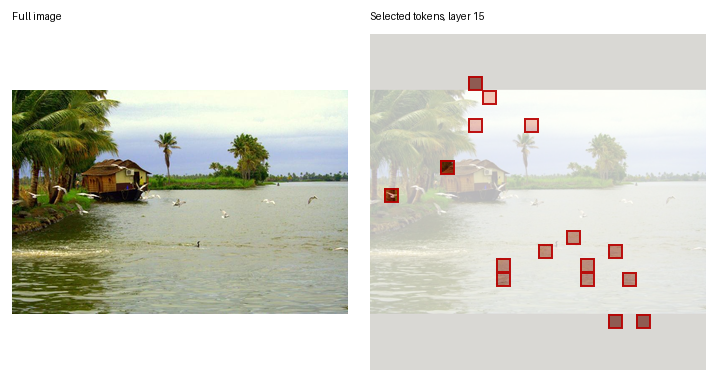

Sparse answer: The photo shows a beach scene with a body of water, a house, and a flock of birds flying over the water.
Selected original patches: 16
Trace layers: [2, 6, 15]
Seconds: 2.14
----------------------------------------------------------------------------------------------------


### Row 98: `TEXTVQA_VAL_008` | `ocr`

Question: what company is listed on the tape on the wall?
Ground truth: consumer reports
equal token num until now: 64.8125 ,total_layers_cuda_time:3520.6051025390625,TFLOPs_avg_sample:0.890672775168


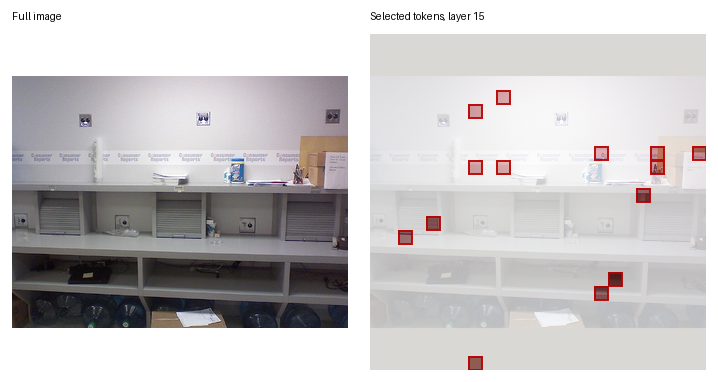

Sparse answer: The company listed on the tape on the wall is "Sun Microsystems."
Selected original patches: 14
Trace layers: [2, 6, 15]
Seconds: 1.65
----------------------------------------------------------------------------------------------------
Done.
Trace JSONL: /kaggle/working/sparse_selected_token_visualizations/selected_token_traces.jsonl


In [4]:
run_selected_token_visualization()